In [1]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import h3
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Polygon, Point, box
from shapely.strtree import STRtree
from math import pi, cos, sin, exp, sqrt
from pyproj import Transformer
from math import pi, cos, sin, exp, sqrt, radians, atan2
import statsmodels.api as sm
import statsmodels.formula.api as smf
import shapely.geometry as geom
import json
import os

In [2]:
RESOLUTION = 7

In [3]:
def process_city_data(lade_selected, input_crs="EPSG:4326", h3_res=RESOLUTION):

    # --- Step 1: Create bounding box ---
    min_lon, min_lat = lade_selected['customer_lng'].min(), lade_selected['customer_lat'].min()
    max_lon, max_lat = lade_selected['customer_lng'].max(), lade_selected['customer_lat'].max()
    geometry = box(min_lon, min_lat, max_lon, max_lat)

    # --- Step 2: Convert bounding box to H3 LatLngPoly (NO BUFFER RING) ---
    outer_ring = [[y, x] for x, y in geometry.exterior.coords[:]]
    latlng_poly = h3.LatLngPoly(outer_ring)
    candidate_cells = set(h3.polygon_to_cells(latlng_poly, res=h3_res))

    # --- Step 3: Convert H3 cells to polygons and create GeoDataFrame ---
    polygons = [
        Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])
        for cell in candidate_cells
    ]
    candidate_gdf = gpd.GeoDataFrame({'h3_index': list(candidate_cells), 'geometry': polygons},
                                     crs="EPSG:4326")

    # --- Step 4: Filter hexes intersecting bounding box (safety step) ---
    intersecting_hexes = candidate_gdf[candidate_gdf.geometry.intersects(geometry)].copy()

    # --- Step 5: Prepare vendor/customer points ---
    vendor_points = gpd.GeoSeries(
        [Point(xy) for xy in zip(lade_selected['vendor_lng'], lade_selected['vendor_lat'])],
        crs=input_crs
    )
    customer_points = gpd.GeoSeries(
        [Point(xy) for xy in zip(lade_selected['customer_lng'], lade_selected['customer_lat'])],
        crs=input_crs
    )

    # Convert to EPSG:4326 if needed
    if input_crs != "EPSG:4326":
        vendor_points = vendor_points.to_crs("EPSG:4326")
        customer_points = customer_points.to_crs("EPSG:4326")

    city_boundary = intersecting_hexes.unary_union

    vendor_inside = vendor_points.within(city_boundary).to_numpy()
    customer_inside = customer_points.within(city_boundary).to_numpy()

    # --- Step 6: Filter dataset ---
    city_processed_df = lade_selected[vendor_inside & customer_inside].reset_index(drop=True)

    # --- Step 7: Assign H3 indices ---
    city_processed_df['vendor_h3'] = city_processed_df.apply(
        lambda row: h3.latlng_to_cell(row['vendor_lat'], row['vendor_lng'], h3_res), axis=1)
    city_processed_df['customer_h3'] = city_processed_df.apply(
        lambda row: h3.latlng_to_cell(row['customer_lat'], row['customer_lng'], h3_res), axis=1)

    # --- Step 8: Aggregate vendor/customer counts per hex ---
    unique_vendor_counts = (
        city_processed_df
        .drop_duplicates(subset=['vendor_lat', 'vendor_lng', 'vendor_h3'])
        .groupby('vendor_h3')
        .size()
        .reset_index(name='num_vendors')
    )

    customer_counts = (
        city_processed_df
        .groupby('customer_h3')
        .size()
        .reset_index(name='num_customers')
    )

    # --- Step 9: Merge counts into hex GeoDataFrame ---
    intersecting_hexes['h3_index'] = intersecting_hexes['h3_index'].astype(str)

    merged = intersecting_hexes.merge(
        unique_vendor_counts, left_on='h3_index', right_on='vendor_h3', how='left'
    ).merge(
        customer_counts, left_on='h3_index', right_on='customer_h3', how='left'
    )

    merged['num_vendors'] = merged['num_vendors'].fillna(0).astype(int)
    merged['num_customers'] = merged['num_customers'].fillna(0).astype(int)

    # --- Step 10: Filter out empty hexes ---
    merged = merged.loc[~((merged['num_vendors'] == 0) & (merged['num_customers'] == 0))].copy()

    return city_processed_df, merged

In [4]:
def plot_vendor_customer_counts(merged_gdf):
    merged_3857 = merged_gdf.to_crs(epsg=3857)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # --- Vendors ---
    merged_3857.plot(
        column='num_vendors',
        ax=axes[0],
        legend=True,
        cmap='OrRd',
        alpha=0.6,
        edgecolor='grey',
        linewidth=0.2,
        missing_kwds={"color": "lightgrey"},
    )
    ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.Positron)
    axes[0].set_axis_off()
    axes[0].set_title("Vendors per H3 Cell", fontsize=14)

    # --- Customers ---
    merged_3857.plot(
        column='num_customers',
        ax=axes[1],
        legend=True,
        cmap='Blues',
        alpha=0.6,
        edgecolor='grey',
        linewidth=0.2,
        missing_kwds={"color": "lightgrey"},
    )
    ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.Positron)
    axes[1].set_axis_off()
    axes[1].set_title("Customers per H3 Cell", fontsize=14)

    plt.tight_layout()
    plt.show()


In [5]:
def process_od_pairs(city_processed_df, crs_epsg=4326):
    # --- STEP 1: Vectorized haversine distance calculation ---
    def haversine_np(lat1, lon1, lat2, lon2):
        """Compute great-circle distance between two lat/lon points in km."""
        R = 6371  # Earth radius in km
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
        return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    # --- STEP 2: Build OD pairs directly from vendor/customer H3 cells ---
    df = (
        city_processed_df.groupby(['vendor_h3', 'customer_h3'])
        .size()
        .reset_index(name='flow')
        .rename(columns={'vendor_h3': 'origin', 'customer_h3': 'destination'})
    )

    # --- STEP 3: Filter out zero or extremely large flows early ---
    df = df[(df['flow'] > 0) & (df['flow'] <= 100)]

    # --- STEP 4: Compute centroids for relevant H3 hexes only ---
    unique_hex = pd.unique(df[['origin', 'destination']].values.ravel())
    centroids = {h: h3.cell_to_latlng(h) for h in unique_hex}

    df['o_lat'] = df['origin'].map(lambda h: centroids[h][0])
    df['o_lon'] = df['origin'].map(lambda h: centroids[h][1])
    df['d_lat'] = df['destination'].map(lambda h: centroids[h][0])
    df['d_lon'] = df['destination'].map(lambda h: centroids[h][1])

    # --- STEP 5: Compute travel cost (distance in km) ---
    df['cost'] = haversine_np(
        df['o_lat'].values,
        df['o_lon'].values,
        df['d_lat'].values,
        df['d_lon'].values
    )

    # --- STEP 6: Compute marginal totals for origins (O) and destinations (D) ---
    O = df.groupby('origin')['flow'].sum().rename('O')
    D = df.groupby('destination')['flow'].sum().rename('D')

    df = df.merge(O, left_on='origin', right_index=True)
    df = df.merge(D, left_on='destination', right_index=True)

    # --- STEP 7: Add log-transformed variables ---
    df['log_O'] = np.log(df['O'])
    df['log_D'] = np.log(df['D'])
    df['log_cost'] = np.log(df['cost'] * 1000 + 1)   # convert km to meters, then log
    df['log_flow'] = np.log(df['flow'])

    # --- STEP 8: Drop intermediate coordinate columns for clean output ---
    df = df.drop(columns=['o_lat', 'o_lon', 'd_lat', 'd_lon'])

    return df


# **LADE DATASET**

In [6]:
for city in ['sh', 'hz', 'cq']:

    lade_delivery = pd.read_csv('../data/lade_data/lade_delivery_' + city + '.csv')
    lade_selected = lade_delivery[['accept_gps_lng', 'accept_gps_lat', 'delivery_gps_lng', 'delivery_gps_lat']].rename(columns={
        'accept_gps_lng':'vendor_lng', 'accept_gps_lat':'vendor_lat', 'delivery_gps_lng':'customer_lng', 'delivery_gps_lat':'customer_lat'}).dropna()

    mask = True
    for col in ["customer_lng", "customer_lat", "vendor_lng", "vendor_lat"]:
        mask &= lade_selected[col].between(
            lade_selected[col].quantile(0.005), lade_selected[col].quantile(0.995)
        )
    lade_selected = lade_selected.loc[mask]

    city_processed_df, merged = process_city_data(lade_selected, h3_res=RESOLUTION)
    
    final_lade_df = process_od_pairs(city_processed_df, crs_epsg=4326)

    final_lade_df.to_csv('flow_df_for_r_lade_' + city + '.csv')
    print('Saved flow_df_for_r_lade_' + city + '.csv')


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Saved flow_df_for_r_lade_sh.csv


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Saved flow_df_for_r_lade_hz.csv


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Saved flow_df_for_r_lade_cq.csv


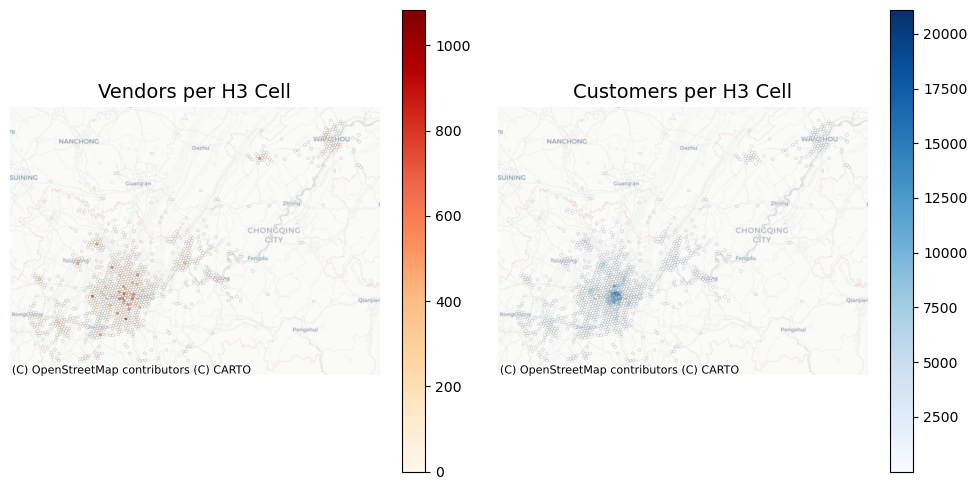

In [7]:
plot_vendor_customer_counts(merged)

In [8]:
final_lade_df

,origin,destination,flow,cost,O,D,log_O,log_D,log_cost,log_flow
0,8740190ceffffff,874019009ffffff,3,15.182337,588,5,6.376727,1.609438,9.627954,1.098612
1,8740190ceffffff,874019019ffffff,3,13.832346,588,3,6.376727,1.098612,9.534837,1.098612
2,8740190ceffffff,87401901affffff,19,15.139407,588,19,6.376727,2.944439,9.625122,2.944439
4,8740190ceffffff,874019050ffffff,12,12.412434,588,12,6.376727,2.484907,9.426535,2.484907
5,8740190ceffffff,874019053ffffff,36,10.326101,588,36,6.376727,3.583519,9.242527,3.583519
...,...,...,...,...,...,...,...,...,...,...
2171,8740f4922ffffff,8740f492bffffff,1,8.732735,329,1,5.796058,0.000000,9.074948,0.000000
2172,8740f4922ffffff,8740f4930ffffff,60,3.951106,329,60,5.796058,4.094345,8.282004,4.094345
2173,8740f4922ffffff,8740f4931ffffff,31,2.265443,329,31,5.796058,3.433987,7.725967,3.433987
2174,8740f4922ffffff,8740f4932ffffff,1,5.985433,329,1,5.796058,0.000000,8.697251,0.000000


# **DUBAI DATASET**

In [9]:
raw_dubai_df = pd.read_csv('../data/talabat_sample.csv')[['vendor_lat', 'vendor_lng', 'customer_lat', 'customer_lng']]

city_processed_df, merged = process_city_data(raw_dubai_df, h3_res=RESOLUTION)

final_dubai_df = process_od_pairs(city_processed_df, crs_epsg=4326)

final_dubai_df.to_csv('flow_df_for_r_dubai.csv')

/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


In [10]:
final_dubai_df

,origin,destination,flow,cost,O,D,log_O,log_D,log_cost,log_flow
0,8743a0203ffffff,8743a1223ffffff,1,108.329370,6,328,1.791759,5.793014,11.592941,0.000000
1,8743a0203ffffff,8743a1224ffffff,1,106.089830,6,845,1.791759,6.739337,11.572051,0.000000
2,8743a0203ffffff,8743a1225ffffff,2,108.335124,6,598,1.791759,6.393591,11.592994,0.693147
3,8743a0203ffffff,8743a1226ffffff,2,104.939336,6,670,1.791759,6.507278,11.561147,0.693147
4,8743a0221ffffff,8743a0226ffffff,1,4.446659,2,1,0.693147,0.000000,8.400133,0.000000
...,...,...,...,...,...,...,...,...,...,...
6983,8743ae522ffffff,8743accb4ffffff,2,120.367222,34,406,3.526361,6.006353,11.698311,0.693147
6984,8743ae522ffffff,8743accb6ffffff,1,118.102024,34,339,3.526361,5.826000,11.679313,0.000000
6985,8743ae522ffffff,8743acd99ffffff,1,124.902371,34,443,3.526361,6.093570,11.735296,0.000000
6986,8743ae528ffffff,8743aec9cffffff,1,14.241044,1,1,0.000000,0.000000,9.563954,0.000000


# **Amazon US Dataset**

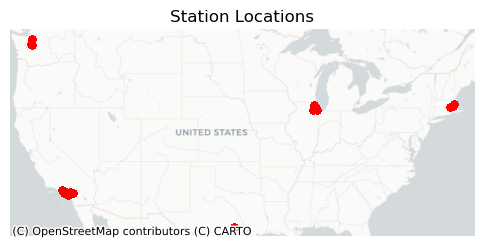

In [ ]:
data_dir = os.path.expanduser('~/.rc-cli/data/model_build_inputs/')
file_path = os.path.join(data_dir, 'route_data.json')
with open(file_path, 'r') as f:
    data = json.load(f)

amazon_df = pd.json_normalize(data)
amazon_df = pd.DataFrame(data).transpose()

# --- Extract station coordinates and dropoffs ---
def extract_coords(stops_dict):
    station_coord = None
    dropoffs = []
    for stop in stops_dict.values():
        if stop['type'] == 'Station':
            station_coord = (stop['lat'], stop['lng'])
        elif stop['type'] == 'Dropoff':
            dropoffs.append((stop['lat'], stop['lng']))
    return pd.Series([station_coord, dropoffs])

amazon_df[['station', 'dropoffs']] = amazon_df['stops'].apply(extract_coords)

gdf_stations = gpd.GeoDataFrame(
    amazon_df,
    geometry=amazon_df['station'].apply(lambda coord: Point(coord[1], coord[0]) if coord else None),
    crs="EPSG:4326"
)
gdf_stations = gdf_stations.dropna(subset=['geometry'])  # Drop rows where station is None

# --- Project to Web Mercator for plotting ---
gdf_stations = gdf_stations.to_crs(epsg=3857)

# --- Plot stations (optional) ---
fig, ax = plt.subplots(figsize=(6, 6))
gdf_stations.plot(ax=ax, color='red', markersize=20)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.title("Station Locations")
plt.show()

# --- Define bounding boxes with buffer for regions ---
bbox_chicago = {'lat_min': 40.0, 'lat_max': 43.5, 'lon_min': -91.5, 'lon_max': -85.0}
bbox_la = {'lat_min': 31.0, 'lat_max': 43.0, 'lon_min': -126.0, 'lon_max': -113.0}
bbox_washington = {'lat_min': 45.0, 'lat_max': 49.0, 'lon_min': -125.0, 'lon_max': -116.5}
bbox_boston = {'lat_min': 41.0, 'lat_max': 43.0, 'lon_min': -73.75, 'lon_max': -69.75}
bbox_austin = {'lat_min': 25.5, 'lat_max': 36.5, 'lon_min': -106.0, 'lon_max': -92.0}

# --- Filter dataframes by bounding box ---
def filter_by_bbox(df, bbox):
    return df[
        (df['station'].apply(lambda x: x[0] if x else None) >= bbox['lat_min']) &
        (df['station'].apply(lambda x: x[0] if x else None) <= bbox['lat_max']) &
        (df['station'].apply(lambda x: x[1] if x else None) >= bbox['lon_min']) &
        (df['station'].apply(lambda x: x[1] if x else None) <= bbox['lon_max'])
    ]

df_chicago = filter_by_bbox(amazon_df, bbox_chicago)
df_la = filter_by_bbox(amazon_df, bbox_la)
df_washington = filter_by_bbox(amazon_df, bbox_washington)
df_boston = filter_by_bbox(amazon_df, bbox_boston)
df_austin = filter_by_bbox(amazon_df, bbox_austin)


In [ ]:
# --- Explode dropoffs into rows with separate vendor and customer lat/lng ---
def explode_dropoffs(df_region):
    if 'dropoffs' not in df_region.columns:
        print("No dropoffs column in this DataFrame")
        return pd.DataFrame(columns=['vendor_lat', 'vendor_lng', 'customer_lat', 'customer_lng'])

    # Filter rows with valid non-empty dropoffs
    df_filtered = df_region[df_region['dropoffs'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

    if df_filtered.empty:
        print("No valid dropoffs found for this region")
        return pd.DataFrame(columns=['vendor_lat', 'vendor_lng', 'customer_lat', 'customer_lng'])

    # Explode dropoffs to one dropoff per row
    exploded = df_filtered.explode('dropoffs').reset_index(drop=True)
    exploded['vendor_lat'] = exploded['station'].apply(lambda x: x[0] if x else None)
    exploded['vendor_lng'] = exploded['station'].apply(lambda x: x[1] if x else None)
    exploded['customer_lat'] = exploded['dropoffs'].apply(lambda x: x[0] if x else None)
    exploded['customer_lng'] = exploded['dropoffs'].apply(lambda x: x[1] if x else None)

    # Return only relevant columns
    return exploded[['vendor_lat', 'vendor_lng', 'customer_lat', 'customer_lng']]

# Apply explode_dropoffs for each region
df_chicago_exploded = explode_dropoffs(df_chicago)
df_la_exploded = explode_dropoffs(df_la)
df_washington_exploded = explode_dropoffs(df_washington)
df_boston_exploded = explode_dropoffs(df_boston)
df_austin_exploded = explode_dropoffs(df_austin)

In [ ]:
states_dfs = {
    'chicago': df_chicago_exploded,
    'la': df_la_exploded,
    'washington': df_washington_exploded,
    'boston': df_boston_exploded,
    'austin': df_austin_exploded,
}

for state_name, raw_df in states_dfs.items():
    print(f"Processing {state_name}...")
    city_processed_df, merged_hexes_gdf = process_city_data(raw_df, h3_res=RESOLUTION)
    od_flow_df = process_od_pairs(city_processed_df)
    output_filename = f'flow_df_for_r_{state_name}.csv'
    od_flow_df.to_csv(output_filename, index=False)


Processing illinois...


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Processing california...


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Processing washington...


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Processing massachusetts...


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


Processing texas...


/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


In [ ]:
city_processed_df, merged_hexes_gdf = process_city_data(states_dfs['chicago'], h3_res=RESOLUTION)
od_flow_df = process_od_pairs(city_processed_df)

od_flow_df.describe()

/var/folders/n6/07flntc946j046ynznszq86w0000gn/T/ipykernel_2998/3525602194.py:39: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_boundary = intersecting_hexes.unary_union


,flow,cost,O,D,log_O,log_D,log_cost,log_flow
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000
mean,39.328713,17.674045,6186.548515,41.281188,8.648998,3.199560,9.643586,3.146649
std,30.444115,7.493347,1901.547217,31.457583,0.468344,1.272496,0.693487,1.270694
min,1.000000,0.000000,1424.000000,1.000000,7.261225,0.000000,0.000000,0.000000
25%,13.000000,12.482536,4019.000000,13.000000,8.298788,2.564949,9.432166,2.564949
50%,33.000000,17.649018,6790.000000,36.000000,8.823206,3.583519,9.778492,3.496508
75%,65.000000,22.988914,7628.000000,68.000000,8.939581,4.219508,10.042811,4.174387
max,100.000000,36.130779,7628.000000,117.000000,8.939581,4.762174,10.494928,4.605170


In [15]:
od_flow_df

,origin,destination,flow,cost,O,D,log_O,log_D,log_cost,log_flow
0,872664cf2ffffff,872664190ffffff,2,20.077988,4019,2,8.298788,0.693147,9.907429,0.693147
1,872664cf2ffffff,872664191ffffff,24,22.510802,4019,24,8.298788,3.178054,10.021795,3.178054
2,872664cf2ffffff,872664192ffffff,1,19.328202,4019,1,8.298788,0.000000,9.869372,0.000000
3,872664cf2ffffff,872664193ffffff,74,21.690039,4019,74,8.298788,4.304065,9.984655,4.304065
4,872664cf2ffffff,872664194ffffff,57,18.629300,4019,57,8.298788,4.043051,9.832545,4.043051
...,...,...,...,...,...,...,...,...,...,...
964,872759a81ffffff,872759ba8ffffff,95,19.625951,7628,95,8.939581,4.553877,9.884659,4.553877
966,872759a81ffffff,872759baaffffff,19,18.062790,7628,19,8.939581,2.944439,9.801665,2.944439
968,872759a81ffffff,872759badffffff,50,21.368369,7628,50,8.939581,3.912023,9.969714,3.912023
969,872759a81ffffff,872759baeffffff,20,20.439857,7628,20,8.939581,2.995732,9.925291,2.995732
